# Decision Tree Classification Example
# This example uses the Iris dataset to show how a decision tree works.
# It includes accuracy, model variance, manual prediction, and plots.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score



In [13]:
dataaa=sns.load_dataset("iris")
dataaa.sample(5)


,sepal_length,sepal_width,petal_length,petal_width,species
41,4.5,2.3,1.3,0.3,setosa
68,6.2,2.2,4.5,1.5,versicolor
47,4.6,3.2,1.4,0.2,setosa
30,4.8,3.1,1.6,0.2,setosa
17,5.1,3.5,1.4,0.3,setosa


In [5]:
# Load dataset
iris = load_iris()


In [6]:
irsss = pd.DataFrame(iris.data, columns=iris.feature_names)
irsss.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
96,5.7,2.9,4.2,1.3
135,7.7,3.0,6.1,2.3
117,7.7,3.8,6.7,2.2
28,5.2,3.4,1.4,0.2
115,6.4,3.2,5.3,2.3


In [8]:

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='species')

# Show first few rows
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [15]:
X.shape

(150, 4)

In [16]:
y.shape

(150,)

In [17]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('Training set size:', X_train.shape[0])
print('Testing set size:', X_test.shape[0])
print('\nClass distribution in training set:')
print(y_train.value_counts().sort_index())

Training set size: 112
Testing set size: 38

Class distribution in training set:
species
0    38
1    37
2    37
Name: count, dtype: int64


In [18]:
# Decision tree model
dt_model = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [19]:

# Predictions
predictions = dt_model.predict(X_test)


In [20]:

# Accuracy
accuracy = accuracy_score(y_test, predictions)
print('Decision Tree Accuracy:', round(accuracy, 4))


Decision Tree Accuracy: 0.8947


In [21]:


# Variance estimation using repeated train/test splits
rng = np.random.RandomState(42)
accuracies = []
for i in range(20):
    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
        X, y, test_size=0.25, random_state=rng.randint(0, 1000), stratify=y
    )
    model_i = DecisionTreeClassifier(random_state=42, max_depth=3)
    model_i.fit(X_train_i, y_train_i)
    pred_i = model_i.predict(X_test_i)
    acc_i = accuracy_score(y_test_i, pred_i)
    accuracies.append(acc_i)

accuracies = np.array(accuracies)
variance = accuracies.var()
print('\nVariance of Accuracy Across 20 Random Splits:', round(variance, 6))
print('Mean Accuracy Across 20 Random Splits:', round(accuracies.mean(), 4))
print('Std Deviation:', round(accuracies.std(), 4))


Variance of Accuracy Across 20 Random Splits: 0.000734
Mean Accuracy Across 20 Random Splits: 0.9526
Std Deviation: 0.0271


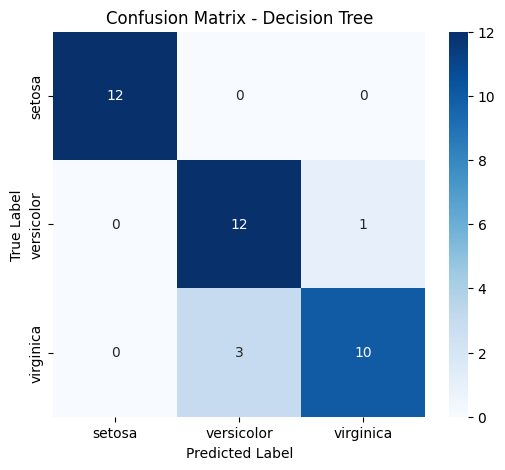

In [17]:
# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



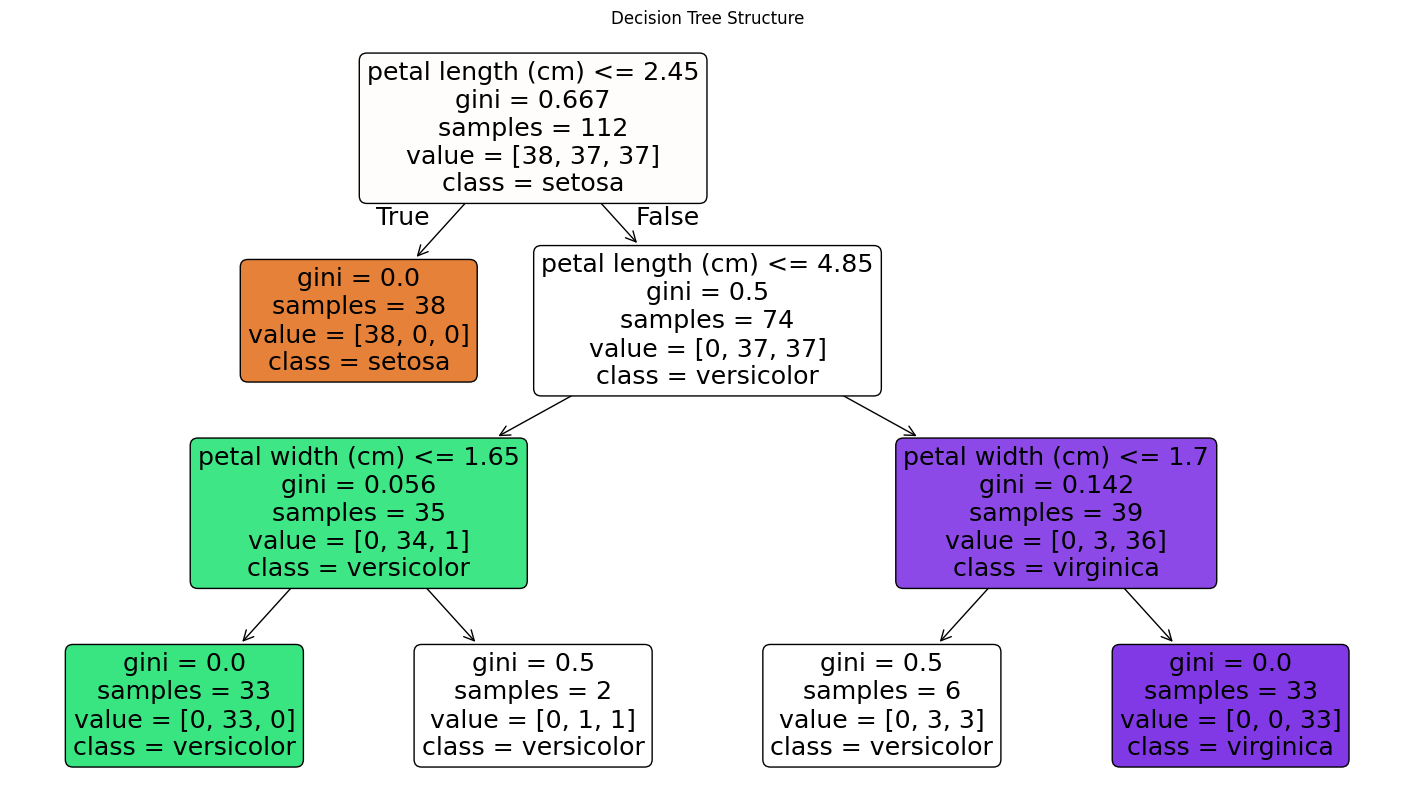

In [23]:

# Plot tree
plt.figure(figsize=(18, 10))
plot_tree(dt_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title('Decision Tree Structure')
plt.show()

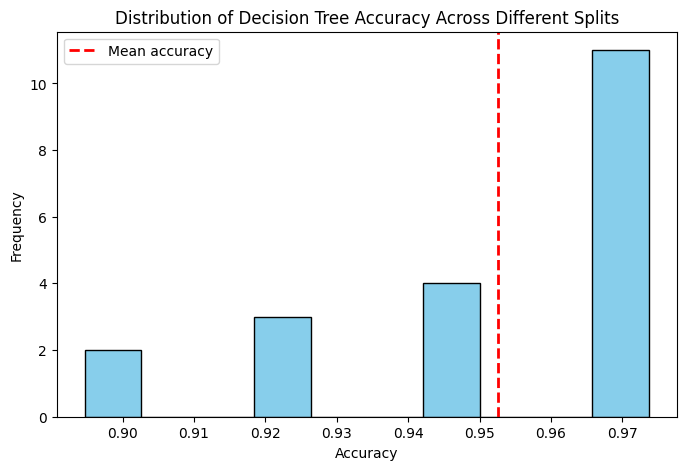

In [19]:

# Plot accuracy distribution across random splits
plt.figure(figsize=(8, 5))
plt.hist(accuracies, bins=10, color='skyblue', edgecolor='black')
plt.axvline(accuracies.mean(), color='red', linestyle='--', linewidth=2, label='Mean accuracy')
plt.title('Distribution of Decision Tree Accuracy Across Different Splits')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [28]:
# Manual prediction function
# Example input: [sepal length, sepal width, petal length, petal width]
manual_sample = np.array([[6.2	,2.2	,4.5,	1.5]])
manual_pred = dt_model.predict(manual_sample)[0]
manual_class = iris.target_names[manual_pred]


d:\ANN_PTROJECT\penve\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [29]:

print('Manual sample input:', manual_sample[0])
print('Predicted class:', manual_class)

# Show tree decision path for the manual sample
node_indicator = dt_model.decision_path(manual_sample)
print('\nDecision path for manual sample:')
print(node_indicator.toarray())

# Also show the actual probability output for the sample
print('\nPrediction probabilities:')
print(dt_model.predict_proba(manual_sample))

Manual sample input: [6.2 2.2 4.5 1.5]
Predicted class: versicolor

Decision path for manual sample:
[[1 0 1 1 1 0 0 0 0]]

Prediction probabilities:
[[0. 1. 0.]]


d:\ANN_PTROJECT\penve\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
d:\ANN_PTROJECT\penve\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
